In [1]:
# Cell 1: Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import random
import csv

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.8.0+cu126
CUDA available: True


In [2]:
# Cell 2: Load preprocessed data and vocabulary
data_root = "./dataset"
artifacts_dir = os.path.join(data_root, "imdb_artifacts")

# Load vocabulary
vocab_path = os.path.join(artifacts_dir, "vocab.json")
with open(vocab_path, "r", encoding="utf-8") as f:
    vocab = json.load(f)

print("Vocabulary size:", len(vocab))

# Load datasets
train_ids, train_labels = torch.load(os.path.join(artifacts_dir, "train_dataset.pt"))
val_ids, val_labels = torch.load(os.path.join(artifacts_dir, "val_dataset.pt"))
test_ids, test_labels = torch.load(os.path.join(artifacts_dir, "test_dataset.pt"))

print(f"Training samples: {len(train_ids)}")
print(f"Validation samples: {len(val_ids)}")
print(f"Test samples: {len(test_ids)}")

Vocabulary size: 28083
Training samples: 17499
Validation samples: 3751
Test samples: 3750


In [3]:
# Cell 3: Define the Dataset class (same as in preprocessing)
class IMDBVarLenDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

# Collate function for variable length sequences
def collate_fn(batch, pad_id=0):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    padded = torch.nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=pad_id)
    mask = (padded != pad_id).long()
    labels = torch.stack(labels)
    return padded, labels, lengths, mask

# Create datasets and dataloaders
batch_size = 32
train_dataset = IMDBVarLenDataset(train_ids, train_labels)
val_dataset = IMDBVarLenDataset(val_ids, val_labels)
test_dataset = IMDBVarLenDataset(test_ids, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                         collate_fn=lambda b: collate_fn(b, pad_id=0))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                       collate_fn=lambda b: collate_fn(b, pad_id=0))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                        collate_fn=lambda b: collate_fn(b, pad_id=0))

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [4]:
# Cell 4: Define the LSTM model with random embeddings
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, 
                 dropout, pad_idx):
        super().__init__()
        
        # Random embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        
        # LSTM layer
        self.lstm = nn.LSTM(embedding_dim, 
                           hidden_dim, 
                           num_layers=n_layers, 
                           bidirectional=False,  # Using unidirectional for simplicity
                           dropout=dropout if n_layers > 1 else 0,
                           batch_first=True)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout)
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, text, text_lengths):
        # text shape: [batch_size, seq_len]
        
        # Embedding layer
        embedded = self.embedding(text)  # [batch_size, seq_len, embedding_dim]
        
        # Pack padded sequences for efficient computation
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, text_lengths.cpu(), batch_first=True, enforce_sorted=False)
        
        # LSTM layer
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        
        # Unpack sequences
        output, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        
        # Use the final hidden state for classification
        # hidden shape: [num_layers, batch_size, hidden_dim]
        last_hidden = hidden[-1]  # Take the last layer's hidden state
        
        # Apply dropout
        dropped = self.dropout(last_hidden)
        
        # Final fully connected layer
        return self.fc(dropped)

In [5]:
# Cell 5: Model initialization and hyperparameters
# Hyperparameters
VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 100  # Dimension for random embeddings
HIDDEN_DIM = 128
OUTPUT_DIM = 2  # Binary classification (positive/negative)
N_LAYERS = 2
DROPOUT = 0.5
PAD_IDX = 0  # Padding token index
LEARNING_RATE = 0.001

# Initialize model
model = SentimentLSTM(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, 
                     N_LAYERS, DROPOUT, PAD_IDX)

print(f"The model has {sum(p.numel() for p in model.parameters()):,} trainable parameters")

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = criterion.to(device)

print(f"Model initialized and moved to {device}")

The model has 3,058,414 trainable parameters
Model initialized and moved to cuda


In [6]:
# Cell 6: Training function
def train(model, iterator, optimizer, criterion, device):
    model.train()  # Set model to training mode
    epoch_loss = 0
    epoch_acc = 0
    
    for batch in iterator:
        text, labels, lengths, mask = batch
        text = text.to(device)
        labels = labels.to(device)
        lengths = lengths.to(device)
        
        optimizer.zero_grad()  # Clear gradients
        
        # Forward pass
        predictions = model(text, lengths)
        
        # Calculate loss
        loss = criterion(predictions, labels)
        
        # Calculate accuracy
        pred_classes = predictions.argmax(dim=1)
        acc = (pred_classes == labels).float().mean()
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc += acc.item()
    
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [7]:
# Cell 7: Evaluation function
def evaluate(model, iterator, criterion, device):
    model.eval()  # Set model to evaluation mode
    epoch_loss = 0
    epoch_acc = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():  # No gradient calculation
        for batch in iterator:
            text, labels, lengths, mask = batch
            text = text.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device)
            
            # Forward pass
            predictions = model(text, lengths)
            
            # Calculate loss
            loss = criterion(predictions, labels)
            
            # Calculate accuracy
            pred_classes = predictions.argmax(dim=1)
            acc = (pred_classes == labels).float().mean()
            
            epoch_loss += loss.item()
            epoch_acc += acc.item()
            
            # Store predictions and labels for metrics calculation
            all_predictions.extend(pred_classes.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate additional metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, average='binary')
    recall = recall_score(all_labels, all_predictions, average='binary')
    f1 = f1_score(all_labels, all_predictions, average='binary')
    
    return (epoch_loss / len(iterator), epoch_acc / len(iterator), 
            accuracy, precision, recall, f1, all_predictions, all_labels)

In [8]:
# Cell 8: Training loop
N_EPOCHS = 50

# Create training history file
history_file = os.path.join(artifacts_dir, "lstm_training_history.csv")
with open(history_file, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 
                    'val_precision', 'val_recall', 'val_f1'])

print(f"Training history will be saved to: {history_file}")

# Lists to store metrics for plotting
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
val_f1_scores = []

print("Starting training...")
for epoch in range(N_EPOCHS):
    # Training
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    
    # Validation
    val_loss, val_acc, val_accuracy, val_precision, val_recall, val_f1, _, _ = evaluate(
        model, val_loader, criterion, device)
    
    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    val_f1_scores.append(val_f1)

    # Save to CSV file
    with open(history_file, 'a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch + 1,
            train_loss,
            train_acc,
            val_loss,
            val_accuracy,
            val_precision,
            val_recall,
            val_f1
        ])
    
    print(f'Epoch: {epoch+1:02}')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {val_loss:.3f} |  Val. Acc: {val_accuracy*100:.2f}%')
    print(f'\t Val. F1: {val_f1:.3f} | Val. Precision: {val_precision:.3f} | Val. Recall: {val_recall:.3f}')

Training history will be saved to: ./dataset\imdb_artifacts\lstm_training_history.csv
Starting training...
Epoch: 01
	Train Loss: 0.580 | Train Acc: 68.58%
	 Val. Loss: 0.472 |  Val. Acc: 79.07%
	 Val. F1: 0.807 | Val. Precision: 0.748 | Val. Recall: 0.876
Epoch: 02
	Train Loss: 0.406 | Train Acc: 82.37%
	 Val. Loss: 0.388 |  Val. Acc: 83.23%
	 Val. F1: 0.825 | Val. Precision: 0.863 | Val. Recall: 0.789
Epoch: 03
	Train Loss: 0.319 | Train Acc: 87.16%
	 Val. Loss: 0.648 |  Val. Acc: 54.39%
	 Val. F1: 0.676 | Val. Precision: 0.524 | Val. Recall: 0.953
Epoch: 04
	Train Loss: 0.376 | Train Acc: 83.71%
	 Val. Loss: 0.339 |  Val. Acc: 85.34%
	 Val. F1: 0.850 | Val. Precision: 0.871 | Val. Recall: 0.830
Epoch: 05
	Train Loss: 0.222 | Train Acc: 91.86%
	 Val. Loss: 0.354 |  Val. Acc: 85.66%
	 Val. F1: 0.849 | Val. Precision: 0.895 | Val. Recall: 0.807
Epoch: 06
	Train Loss: 0.153 | Train Acc: 94.86%
	 Val. Loss: 0.406 |  Val. Acc: 86.72%
	 Val. F1: 0.861 | Val. Precision: 0.903 | Val. Recall:

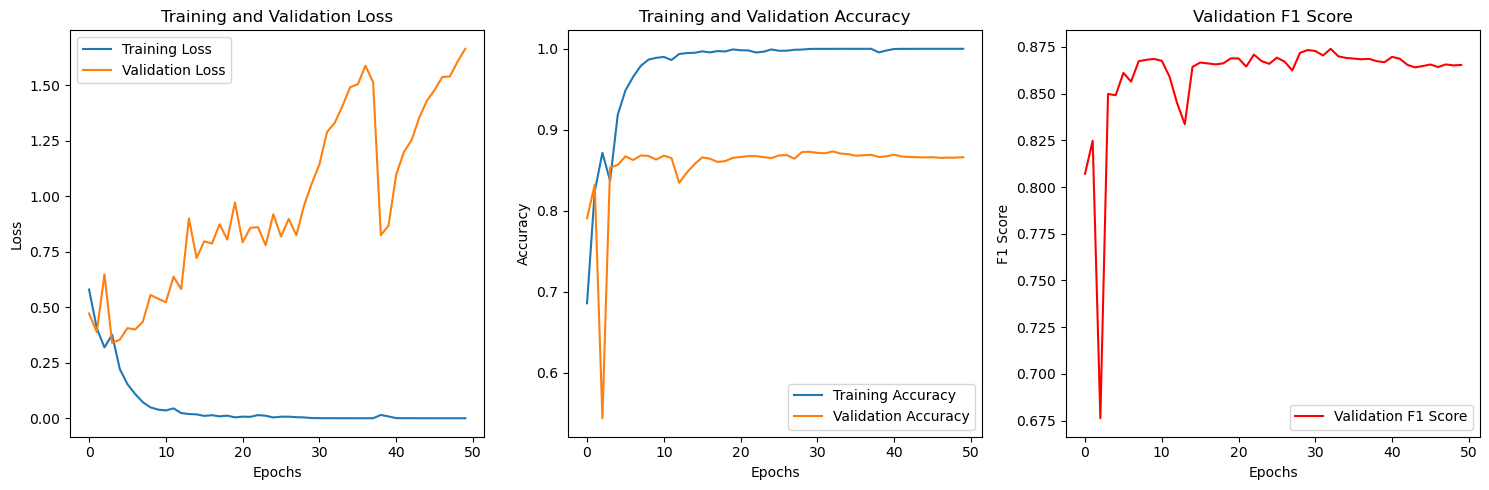

In [9]:
# Cell 9: Plot training history
plt.figure(figsize=(15, 5))

# Plot loss
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot F1 score
plt.subplot(1, 3, 3)
plt.plot(val_f1_scores, label='Validation F1 Score', color='red')
plt.title('Validation F1 Score')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
# Cell 10: Test the model
print("Evaluating on test set...")
test_loss, test_acc, test_accuracy, test_precision, test_recall, test_f1, test_preds, test_true = evaluate(
    model, test_loader, criterion, device)

print(f'Test Results:')
print(f'Loss: {test_loss:.3f} | Accuracy: {test_accuracy*100:.2f}%')
print(f'Precision: {test_precision:.3f} | Recall: {test_recall:.3f} | F1-Score: {test_f1:.3f}')

# Save test results
test_results_file = os.path.join(artifacts_dir, "lstm_test_results.csv")
with open(test_results_file, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['metric', 'value'])
    writer.writerow(['test_loss', test_loss])
    writer.writerow(['test_accuracy', test_accuracy])
    writer.writerow(['test_precision', test_precision])
    writer.writerow(['test_recall', test_recall])
    writer.writerow(['test_f1', test_f1])

print(f"Test results saved to: {test_results_file}")

Evaluating on test set...
Test Results:
Loss: 1.742 | Accuracy: 86.24%
Precision: 0.864 | Recall: 0.861 | F1-Score: 0.862
Test results saved to: ./dataset\imdb_artifacts\lstm_test_results.csv



Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86      1875
    Positive       0.86      0.86      0.86      1875

    accuracy                           0.86      3750
   macro avg       0.86      0.86      0.86      3750
weighted avg       0.86      0.86      0.86      3750



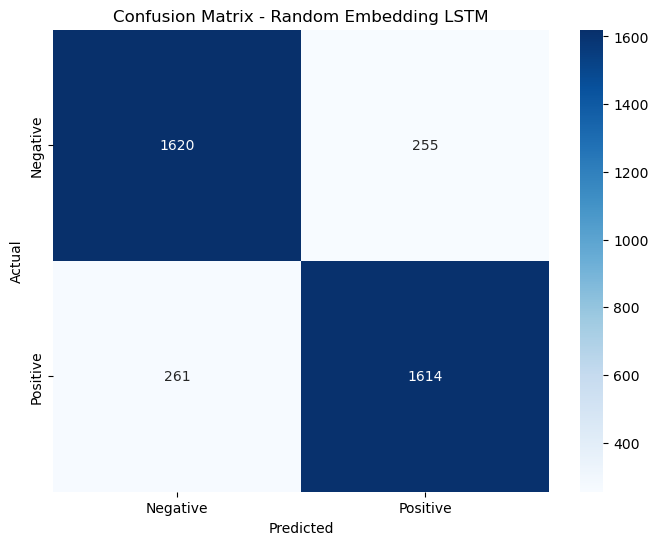

In [11]:
# Cell 11: Detailed classification report and confusion matrix
print("\nDetailed Classification Report:")
print(classification_report(test_true, test_preds, target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(test_true, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Random Embedding LSTM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [12]:
# Cell 12: Save the trained model
model_save_path = os.path.join(artifacts_dir, "lstm_random_embedding_model.pt")
torch.save({
    'model_state_dict': model.state_dict(),
    'vocab_size': VOCAB_SIZE,
    'embedding_dim': EMBEDDING_DIM,
    'hidden_dim': HIDDEN_DIM,
    'output_dim': OUTPUT_DIM,
    'n_layers': N_LAYERS,
    'dropout': DROPOUT,
    'pad_idx': PAD_IDX
}, model_save_path)

print(f"Model saved to {model_save_path}")

Model saved to ./dataset\imdb_artifacts\lstm_random_embedding_model.pt


In [13]:
# Cell 13: Example prediction function
def predict_sentiment(model, sentence, vocab, device, max_length=364):
    model.eval()
    
    # Preprocess the input sentence (same as training preprocessing)
    import re
    import html
    import string
    from nltk.tokenize import TreebankWordTokenizer
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer
    
    def clean_text(text):
        text = re.sub(r'<[^>]+>', ' ', text)
        text = html.unescape(text)
        text = text.lower()
        text = re.sub(r"([!?.])", r" \1 ", text)
        text = re.sub(r"[^a-z0-9'!?.\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text
    
    def tokenize(text):
        tokenizer = TreebankWordTokenizer()
        return tokenizer.tokenize(text)
    
    def handle_negation(tokens):
        out, negate = [], False
        neg_triggers = {"not", "n't", "no", "never"}
        end_punct = {"!", "?", "."}
        for tok in tokens:
            if tok in neg_triggers:
                out.append(tok)
                negate = True
                continue
            if tok in end_punct:
                out.append(tok)
                negate = False
                continue
            if negate and tok.isalpha():
                out.append("NOT_" + tok)
            else:
                out.append(tok)
        return out
    
    def extra_preprocess(tokens):
        stop_words = set(stopwords.words('english'))
        lemmatizer = WordNetLemmatizer()
        tokens = [t for t in tokens if t not in string.punctuation]
        tokens = [t for t in tokens if t.lower() not in stop_words]
        tokens = [t for t in tokens if t.lower() not in {"'s", "'t", "'re", "'ve", "'m", "'d"}]
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
        return tokens
    
    # Process the input sentence
    cleaned = clean_text(sentence)
    tokens = tokenize(cleaned)
    tokens = handle_negation(tokens)
    tokens = extra_preprocess(tokens)
    
    # Convert to indices
    indexed = [vocab.get(token, 1) for token in tokens]  # 1 is UNK index
    indexed = indexed[:max_length]  # Truncate if too long
    
    # Convert to tensor
    tensor = torch.LongTensor(indexed).unsqueeze(0).to(device)
    length = torch.LongTensor([len(indexed)]).to(device)
    
    # Prediction
    with torch.no_grad():
        prediction = model(tensor, length)
        probabilities = torch.softmax(prediction, dim=1)
        predicted_class = prediction.argmax(dim=1).item()
        confidence = probabilities[0][predicted_class].item()
    
    sentiment = "Positive" if predicted_class == 1 else "Negative"
    
    print(f"Review: {sentence}")
    print(f"Sentiment: {sentiment} (confidence: {confidence:.4f})")
    return sentiment, confidence

# Test with example reviews
print("Testing with example reviews:")
print("-" * 50)

example_reviews = [
    "This movie was absolutely fantastic! Great acting and storyline.",
    "Terrible film, waste of time. Poor acting and boring plot.",
    "It was okay, not great but not terrible either.",
    "The cinematography was beautiful but the story was weak."
]

for review in example_reviews:
    predict_sentiment(model, review, vocab, device)
    print("-" * 30)

Testing with example reviews:
--------------------------------------------------
Review: This movie was absolutely fantastic! Great acting and storyline.
Sentiment: Negative (confidence: 0.6361)
------------------------------
Review: Terrible film, waste of time. Poor acting and boring plot.
Sentiment: Negative (confidence: 1.0000)
------------------------------
Review: It was okay, not great but not terrible either.
Sentiment: Negative (confidence: 0.9996)
------------------------------
Review: The cinematography was beautiful but the story was weak.
Sentiment: Negative (confidence: 0.9968)
------------------------------
